<a href="https://colab.research.google.com/github/hmmnyamminji/DL/blob/main/day12_practice3_%EB%B2%88%ED%98%B8%ED%8C%90_%ED%8C%8C%EC%9D%B4%ED%94%84%EB%9D%BC%EC%9D%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 번호판 인식 파이프라인 완성
# 감지 → 1. 여백 크롭 → 2. 전처리 → 3. OCR(allowlist) → 4. 후처리(형식 검증) → 5. 서버 JSON

In [2]:
! pip install EasyOCR

In [3]:
import easyocr
from PIL import Image, ImageDraw, ImageFont, ImageOps #흑백, 대비, 이미지 후처리 도구 (흑백,대비)
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import time, re, json
import numpy as np


import warnings
warnings.filterwarnings("ignore")

In [4]:
# 셀 1. Reader 생성
reader = easyocr.Reader(["ko","en"], gpu=False, verbose=False) # OCR 엔진 객체 생성 (언어를 정하면 모델을 메모리에 로드)

In [5]:
!apt-get -qq install -y fonts-nanum > /dev/null
!rm -rf ~/.cache/matplotlib          # 폰트 캐시 비우기

In [14]:
# OCR 시각화 도구 준비 - 원본 이미지 vs 판독 결과 이미지

import matplotlib.font_manager as fm

# Install Nanum Gothic font
!sudo apt-get update -qq
!sudo apt-get install -y fonts-nanum > /dev/null

# Rebuild font caches (removed the problematic line)
fm.fontManager.addfont("/usr/share/fonts/truetype/nanum/NanumGothic.ttf")

# Find the font path after installation (optional, but good for robustness)
font_path = fm.findfont(fm.FontProperties(family='NanumGothic'))

plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False


def load_font(size=48):
    return ImageFont.truetype(font_path, size)

def draw_ocr_boxes(image_path, results, box_color="red", text_color="blue"):
  img = Image.open(image_path) if isinstance(image_path, str) else image_path
  img = img.convert("RGB")
  d = ImageDraw.Draw(img)
  font = load_font(20)

  for box, text, conf in results:
    points = [tuple(p) for p in box]
    d.line(points + [points[0]], fill=box_color, width=3)
    label = f"{text} ({conf:.2f})"
    label_pos = (points[0][0], max(points[0][1] - 26,0))
    d.text(label_pos, label, fill=text_color, font=font)
  return img

def show_original_and_result(image_path, results):
  original_img = Image.open(image_path) if isinstance(image_path, str) else image_path
  result_img = draw_ocr_boxes(image_path, results)

  fig, axes = plt.subplots(1, 2, figsize=(14, 6))

  axes[0].imshow(original_img, cmap="gray" if original_img.mode == "L" else None)
  axes[0].set_title("원본 이미지")
  axes[0].axis("off")

  axes[1].imshow(result_img)
  axes[1].set_title("OCR  판독 결과")
  axes[1].axis("off")
  plt.show()

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)


In [16]:
SCENE = "scene.jpg"

PLATE_REGION = "서울경기인천대전대구부산광주울산세종강원충북충남전북전남경북경남제주"

PLATE_HANGUL="가나다라마거너더러머버서어저고노도로모보소오조구누두루무부수우주아바사자하허호배" + PLATE_REGION

ALLOW = "0123456789" + PLATE_HANGUL

def ocr(pil_img, **kw): # PIL로 전처리했다면 np.array()로 변환해서 EasyOCR에 넣는다.

  return reader.readtext(np.array(pil_img), **kw) # **kw = 이름 있는 인자들을 통째로 받아 그대로 전달

In [8]:
!pip install ultralytics -q

In [9]:
# YOLO 감지(자르기) 후 OCR
from ultralytics import YOLO

# 한글 차량 번호판만 학습한 YOLO 모델을 허깅페이스에서 다운로드 받아서 사용
from huggingface_hub import hf_hub_download
model_path = hf_hub_download(
    repo_id="sauce-hug/korean-license-plate-detector",
    filename="plate_detect_v1/weights/best.pt"
)
plate_model = YOLO(model_path)
detections = plate_model(SCENE)

boxes = detections[0].boxes

if len(boxes) == 0:
  raise RuntimeError("YOLO가 번호판을 감지하지 못했습니다 - 모델 파일 또는 이미지를 확인하세요.")

# 사진에 차가 여러 대 찍혀 있어 박스가 여러 개 나올 때
# 신뢰도 (confidence)가 가장 높은 박스 하나를 '진짜 번호판'으로 선택
best_idx = boxes.conf.argmax().item() # conf  텐서에서 가장 큰 값의 인덱스
xyxy = boxes.xyxy[best_idx].tolist()
box = tuple(round(v) for v in xyxy)
print(f"YOLO 감지 박스: {box} (신뢰도 {boxes.conf[best_idx]:.2f})")


image 1/1 /content/scene.jpg: 288x416 2 plates, 78.2ms
Speed: 2.7ms preprocess, 78.2ms inference, 1.5ms postprocess per image at shape (1, 3, 288, 416)
YOLO 감지 박스: (652, 715, 896, 782) (신뢰도 0.45)


딱 맞는 크롭 : {'서울32가4567'}


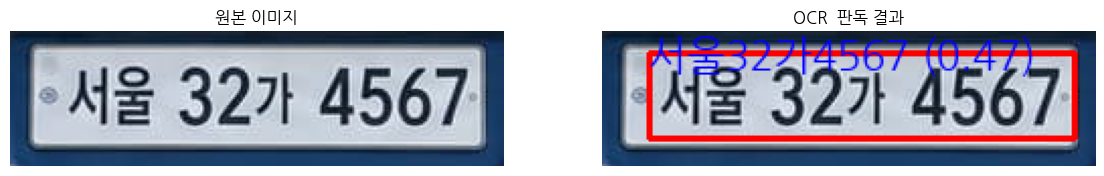

In [17]:
# 셀 2. 딱 맞는 크롭은 글자를 자른다.

tight = Image.open(SCENE).crop(box)
tight_results = ocr(tight, allowlist=ALLOW)
print("딱 맞는 크롭 :", {text for box, text, conf in tight_results})

show_original_and_result(tight, tight_results)

여백 15% 크롭 : {'서울32가4567'}


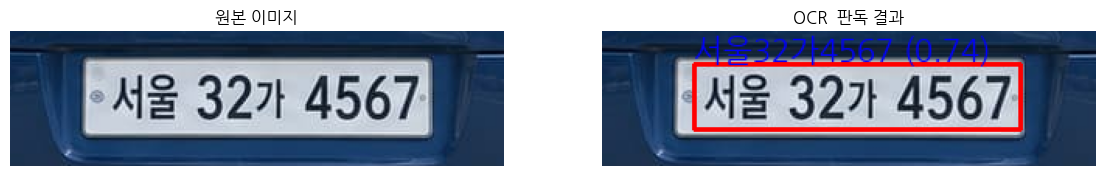

In [19]:
# 셀 3. 1단계 - 여백(padding) 크롭
def crop_with_pad(image_path, box, pad_ratio=0.15): # pad_ration 기본 15%
  img = Image.open(image_path)
  x1, y1, x2, y2 = box
  pw, ph = (x2 - x1) * pad_ratio, (y2 - y1) * pad_ratio # 가로 세로 여백 크기 계산
  return img.crop((
      max(0, x1 - pw),
      max(0, y1 - ph),
      min(img.width, x2 + pw),
      min(img.height, y2 + ph)
  )) # 왼쪽은 0 미만 방지, 오른쪽은 너비

padded = crop_with_pad(SCENE, box)
padded_results = ocr(padded, allowlist=ALLOW) # 패딩이 들어간 이미지롤 easyOCR 글자 인식
print("여백 15% 크롭 :", {text for box, text, conf in padded_results})
show_original_and_result(padded, padded_results)

# 여백은 글자 잘림 방지 기본기

여백+확대+흑백+대비 : {'서울32가4567'}


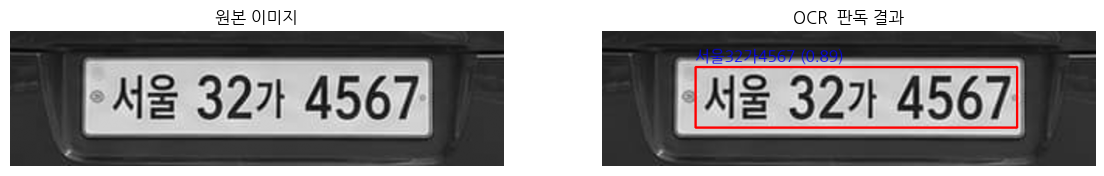

In [20]:
# 셀 3. 2단계 - 전처리 : 확대 + 흑백 + 대비
# resize(2배 확대) → grayscale(흑백) → autocontrast(대비 강화)
pre = ImageOps.autocontrast(ImageOps.grayscale(padded.resize({padded.width * 2, padded.height * 2}))) # (너비x2, 높이x2)로 확대
pre_results = ocr(pre, allowlist=ALLOW)
print("여백+확대+흑백+대비 :", {text for box, text, conf in pre_results})
show_original_and_result(pre, pre_results)


In [22]:
# 셀 3. 3단계 - 후처리: 형식 검증 (정규식)
PLATE_PATTERN = re.compile(r"(?:[가-힣]{2}\s?)?\d{2,3}\n?[가-힣]\n?\d{4}") # (?:...)? 있어도 되고 없어도 됨, \n 공백, \d{4} 숫자4자리
def validate_plate(text):
  m = PLATE_PATTERN.search(text.strip())
  return m.group().replace(" ", "") if m else None

for raw in ["12가3456", "123나4567", "서울12가3456", "12가345", "PIZZA STORE"]: # 테스트
  print(f"{raw} -> {validate_plate(raw)}")

12가3456 -> 12가3456
123나4567 -> 123나4567
서울12가3456 -> 서울12가3456
12가345 -> None
PIZZA STORE -> None



 최종 결과:
{
  "plate_number": "서울32가4567",
  "confidence": 0.742,
  "box": {
    "x1": 0.426,
    "y1": 0.696,
    "x2": 0.586,
    "y2": 0.761
  }
}
인식된 번호판: 서울32가4567


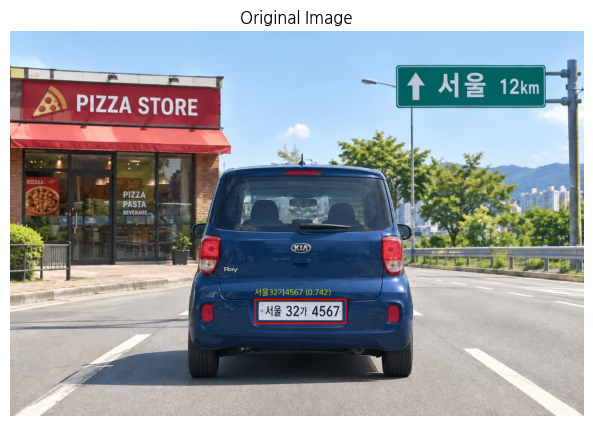

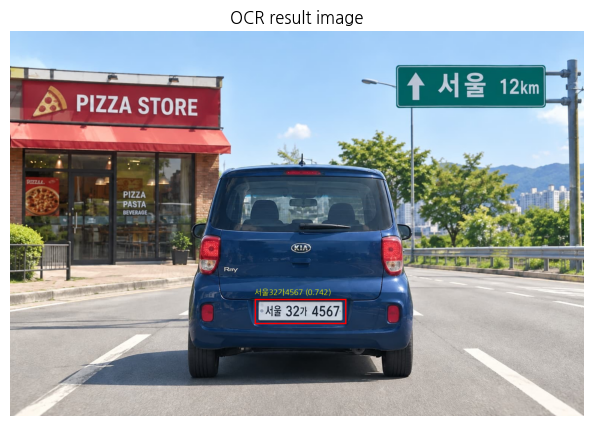

In [28]:
# 셀 4. 완성형 - object_and_read (서버 JSON 반환)
# 감지 박스 → 여백 크롭 → 전처리 → 검증 → JSON 형식 반환

def detect_and_read(image_path, det_box):
  crop = crop_with_pad(image_path, det_box, pad_ratio=0.15) # 1. 여백
  results = ocr(crop, detail=1, allowlist=ALLOW)             # 3. OCR 글자 인식 (detail 기본=1)
  if not results: # 원본 OCR이 실패한 경우에만 확대+흑백+대비 전처리 후 다시 OCR # 2. 전처리
    crop = ImageOps.autocontrast(ImageOps.grayscale(crop.resize((crop.width * 2, crop.height * 2))))
    results = ocr(crop, detail=1, allowlist=ALLOW)
  best = None
  for box, text, conf in results:
    plate = validate_plate(text)                             # 4. 형식 검증(번호판꼴만 통과)
    if plate and (best is None or conf > best["confidence"]):
      W, H = Image.open(image_path).size
      x1, y1, x2, y2 = det_box
      best = {                                              # 5. JSON 형식 반환
          "plate_number": plate,
          "confidence": round(float(conf), 3),
          "box": {
              "x1": round(x1/W, 3),
              "y1": round(y1/H, 3),
              "x2": round(x2/W, 3),
              "y2": round(y2/H, 3)
          },
      }
  return best

result = detect_and_read(SCENE, box)
print("\n 최종 결과:")
print(json.dumps(result, ensure_ascii=False, indent=2))

if result:
  print("인식된 번호판:", result["plate_number"])

original = Image.open(SCENE).convert("RGB")
result_img = original.copy()
draw = ImageDraw.Draw(result_img)
x1, y1, x2, y2 = box
draw.rectangle((x1, y1, x2, y2), outline="red", width=4)

if result:
  label = f"{result['plate_number']} ({result['confidence']:.3f})"
  draw.text((x1, max(0, y1 - 30)), label, fill="yellow", font=load_font(20))

plt.figure(figsize=[14, 5])
plt.imshow(result_img)
plt.axis("off")
plt.title("Original Image")
plt.show()

plt.figure(figsize=[14, 5])
plt.imshow(result_img)
plt.axis("off")
plt.title("OCR result image")
plt.show()